# Actividad 02: Clasificación de Riesgo Académico con Machine Learning

## Contexto

En este notebook se aborda un problema de clasificación binaria cuyo objetivo es predecir el riesgo académico de estudiantes a partir de variables académicas y/o contextuales.

La variable objetivo se define de la siguiente forma:

- 0: Estudiante de bajo riesgo académico
- 1: Estudiante de alto riesgo académico

El modelo utilizado corresponde a un Random Forest.  
El foco del notebook es ejecutar el modelo y mostrar sus resultados, los cuales deberán ser analizados e interpretados en la actividad asociada.

No modifiques el código. Ejecuta las celdas en orden y observa cuidadosamente los resultados.


In [2]:
# librerías
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    auc
)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

In [5]:
# Leer datos
df = pd.read_csv("d_data.csv")
df.head()

,id,year,gender,school_dependence,ivm_colegio,nem,nem_score,rank_score,ptje_ponderado,ptje_leng_paes,ptje_m1_paes,ptje_m2_paes,alerta_cero,deserta,target
0,1,2024,M,Particular Subvencionado,0.0,6.13,751.0,784.0,757.25,865.0,995.0,862.0,Riesgo Bajo,0.0,0
1,4,2024,M,Particular Subvencionado,0.0,6.63,893.0,909.0,795.20,925.0,992.0,858.0,Riesgo Bajo,0.0,0
2,47,2024,M,Particular Subvencionado,0.0,5.70,630.0,638.0,563.60,864.0,661.0,485.0,Riesgo Bajo,0.0,0
3,48,2024,F,Municipal,0.0,6.63,895.0,917.0,676.10,785.0,534.0,412.0,Riesgo Bajo,1.0,0
4,49,2024,M,Particular Subvencionado,0.0,6.28,793.0,795.0,648.60,807.0,598.0,447.0,Riesgo Medio,0.0,1


In [7]:
# Exploración inicial
df.shape

(2480, 15)

In [6]:
# Exploración inicial
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2480 entries, 0 to 2479
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 2480 non-null   int64  
 1   year               2480 non-null   int64  
 2   gender             2480 non-null   object 
 3   school_dependence  2480 non-null   object 
 4   ivm_colegio        2480 non-null   float64
 5   nem                2480 non-null   float64
 6   nem_score          2480 non-null   float64
 7   rank_score         2480 non-null   float64
 8   ptje_ponderado     2480 non-null   float64
 9   ptje_leng_paes     2480 non-null   float64
 10  ptje_m1_paes       2480 non-null   float64
 11  ptje_m2_paes       2480 non-null   float64
 12  alerta_cero        2480 non-null   object 
 13  deserta            2480 non-null   float64
 14  target             2480 non-null   int64  
dtypes: float64(9), int64(3), object(3)
memory usage: 290.8+ KB


In [8]:
# Exploración inicial
df.isna().sum()

id                   0
year                 0
gender               0
school_dependence    0
ivm_colegio          0
nem                  0
nem_score            0
rank_score           0
ptje_ponderado       0
ptje_leng_paes       0
ptje_m1_paes         0
ptje_m2_paes         0
alerta_cero          0
deserta              0
target               0
dtype: int64

In [9]:
# Separación de variables
features = ["ptje_leng_paes", "ptje_m1_paes"]
target = "target"

X = df[features]
y = df[target]

X.shape, y.shape


((2480, 2), (2480,))

In [10]:
# División train / test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=17,
    stratify=y
)


In [11]:
# Definición y entrenamiento del modelo
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=5,
    min_samples_leaf=20,
    random_state=17
)

rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=5, min_samples_leaf=20, n_estimators=300,
                       random_state=17)

In [12]:
# Predicciones
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]


In [13]:
# Métricas de evaluación
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", round(accuracy, 3))
print("Precision:", round(precision, 3))
print("Recall   :", round(recall, 3))
print("F1-score :", round(f1, 3))


Accuracy : 0.679
Precision: 0.726
Recall   : 0.777
F1-score : 0.75


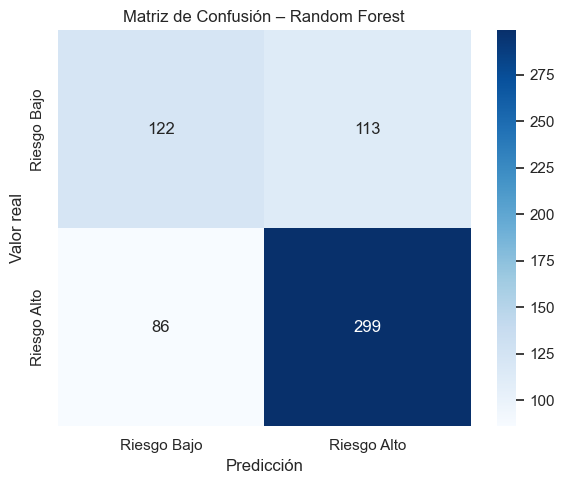

In [14]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Riesgo Bajo", "Riesgo Alto"],
    yticklabels=["Riesgo Bajo", "Riesgo Alto"]
)

plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.title("Matriz de Confusión – Random Forest")
plt.tight_layout()
plt.show()


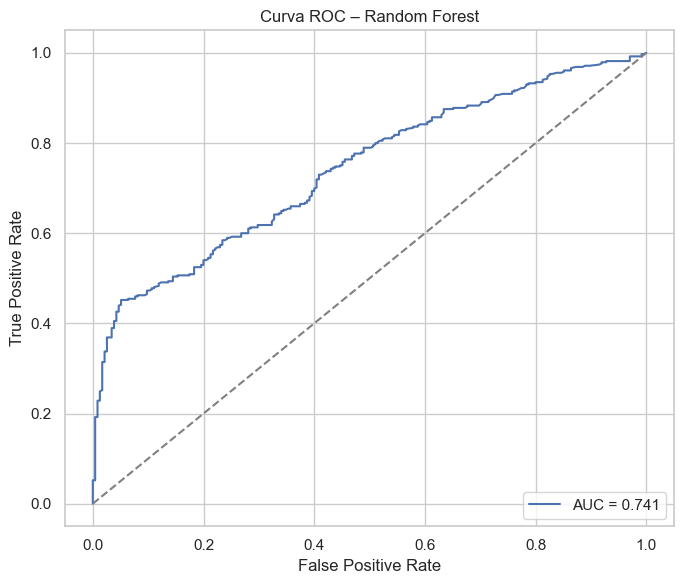

In [15]:
# Curva ROC y AUC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC – Random Forest")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


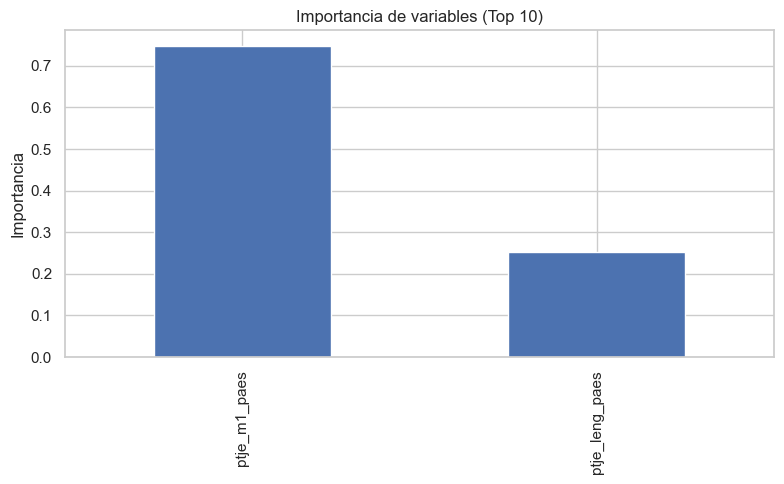

In [16]:
# Importancia de variables
importances = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)


plt.figure(figsize=(8, 5))
importances.head(10).plot(kind="bar")
plt.title("Importancia de variables (Top 10)")
plt.ylabel("Importancia")
plt.tight_layout()
plt.show()



> Conclusiones, comentarios y anotaciones: ...